# 04 - Feature Engineering for RFM Analysis

Creating features for customer segmentation

## Import Libraries

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

print('All Libraries imported!')

All Libraries imported!


## Load Cleaned Data

In [58]:
# Load the cleaned data from previous step
clean_df = pd.read_csv('clean_online_retail.csv')

# Convert InvoiceDate to datetime since its the new clean_online_retail data
clean_df['InvoiceDate'] = pd.to_datetime(clean_df['InvoiceDate'])

# Calculate Revenue column
clean_df['Revenue'] = clean_df['Quantity'] * clean_df['UnitPrice']

print('Data loaded successfully!')
print(f'Total rows: {len(clean_df)}')
print(f'Total customers: {clean_df["CustomerID"].nunique()}')

Data loaded successfully!
Total rows: 392692
Total customers: 4338


## What is RFM Analysis?

RFM stands for:
- **R**ecency: How RECENTLY did they buy?
- **F**requency: How OFTEN do they buy?
- **M**onetary: How MUCH do they spend?

These 3 features tell us EVERYTHING about a customer's value!

## Step 1: Find the MOST RECENT Date in Dataset

We need to set a reference point to calculate Recency

In [59]:
# Find the LAST purchase date in the entire dataset
max_date = clean_df['InvoiceDate'].max()
print(f'Most recent transaction date: {max_date}')

# We'll use this as our reference point (TODAY for the analysis)
# Recency = How many days since max_date
reference_date = max_date + pd.Timedelta(days=1)  # Add 1 day for calculation
print(f'Reference date (TODAY): {reference_date}')

Most recent transaction date: 2011-12-09 12:50:00
Reference date (TODAY): 2011-12-10 12:50:00


## Step 2: Calculate RFM Features

Group by CustomerID and calculate R, F, M for each customer

In [60]:
# Create RFM dataframe
rfm = clean_df.groupby('CustomerID').agg({
    'InvoiceDate': 'max',  # Latest purchase date
    'InvoiceNo': 'nunique',  # Number of unique invoices (purchases)
    'Revenue': 'sum'  # Total revenue spent
})

# Rename columns to be clear
rfm.columns = ['LastPurchaseDate', 'Frequency', 'Monetary']

print('RFM DataFrame created!')
print(rfm.head(10))

RFM DataFrame created!
              LastPurchaseDate  Frequency  Monetary
CustomerID                                         
12346.0    2011-01-18 10:01:00          1  77183.60
12347.0    2011-12-07 15:52:00          7   4310.00
12348.0    2011-09-25 13:13:00          4   1797.24
12349.0    2011-11-21 09:51:00          1   1757.55
12350.0    2011-02-02 16:01:00          1    334.40
12352.0    2011-11-03 14:37:00          8   2506.04
12353.0    2011-05-19 17:47:00          1     89.00
12354.0    2011-04-21 13:11:00          1   1079.40
12355.0    2011-05-09 13:49:00          1    459.40
12356.0    2011-11-17 08:40:00          3   2811.43


## Step 3: Calculate RECENCY

Recency = Days since last purchase

In [61]:
# Calculate Recency (days since last purchase)
rfm['Recency'] = (reference_date - rfm['LastPurchaseDate']).dt.days

print('Recency calculated!')
print(rfm[['LastPurchaseDate', 'Recency']].head(5))

print(f'\nRecency Statistics:')
print(f"Average days since purchase: {rfm['Recency'].mean():.0f} days")
print(f"Max (oldest customer): {rfm['Recency'].max()} days")
print(f"Min (newest customer): {rfm['Recency'].min()} days")

Recency calculated!
              LastPurchaseDate  Recency
CustomerID                             
12346.0    2011-01-18 10:01:00      326
12347.0    2011-12-07 15:52:00        2
12348.0    2011-09-25 13:13:00       75
12349.0    2011-11-21 09:51:00       19
12350.0    2011-02-02 16:01:00      310

Recency Statistics:
Average days since purchase: 93 days
Max (oldest customer): 374 days
Min (newest customer): 1 days


## View the Complete RFM Table

In [62]:
# Remove the LastPurchaseDate column (we don't need it anymore)
rfm = rfm.drop('LastPurchaseDate', axis=1)

# Reorder columns
rfm = rfm[['Recency', 'Frequency', 'Monetary']]

print('\nFinal RFM Table:')
print(rfm.head(20))

print(f'\nTotal customers in RFM: {len(rfm)}')


Final RFM Table:
            Recency  Frequency  Monetary
CustomerID                              
12346.0         326          1  77183.60
12347.0           2          7   4310.00
12348.0          75          4   1797.24
12349.0          19          1   1757.55
12350.0         310          1    334.40
12352.0          36          8   2506.04
12353.0         204          1     89.00
12354.0         232          1   1079.40
12355.0         214          1    459.40
12356.0          23          3   2811.43
12357.0          33          1   6207.67
12358.0           2          2   1168.06
12359.0          58          4   6310.03
12360.0          52          3   2662.06
12361.0         287          1    189.90
12362.0           3         10   5226.23
12363.0         110          2    552.00
12364.0           8          4   1313.10
12365.0         291          2    641.38
12367.0           4          1    168.90

Total customers in RFM: 4338


## RFM Statistics

In [63]:
print('='*60)
print('RFM STATISTICS')
print('='*60)

print('\nRECENCY (Days Since Last Purchase):')
print(rfm['Recency'].describe())

print('\nFREQUENCY (Number of Purchases):')
print(rfm['Frequency'].describe())

print('\nMONETARY (Total Spending in £):')
print(rfm['Monetary'].describe())

print('\n' + '='*60)

RFM STATISTICS

RECENCY (Days Since Last Purchase):
count    4338.000000
mean       92.536422
std       100.014169
min         1.000000
25%        18.000000
50%        51.000000
75%       142.000000
max       374.000000
Name: Recency, dtype: float64

FREQUENCY (Number of Purchases):
count    4338.000000
mean        4.272015
std         7.697998
min         1.000000
25%         1.000000
50%         2.000000
75%         5.000000
max       209.000000
Name: Frequency, dtype: float64

MONETARY (Total Spending in £):
count      4338.000000
mean       2048.688081
std        8985.230220
min           3.750000
25%         306.482500
50%         668.570000
75%        1660.597500
max      280206.020000
Name: Monetary, dtype: float64



## Visualize RFM Distributions

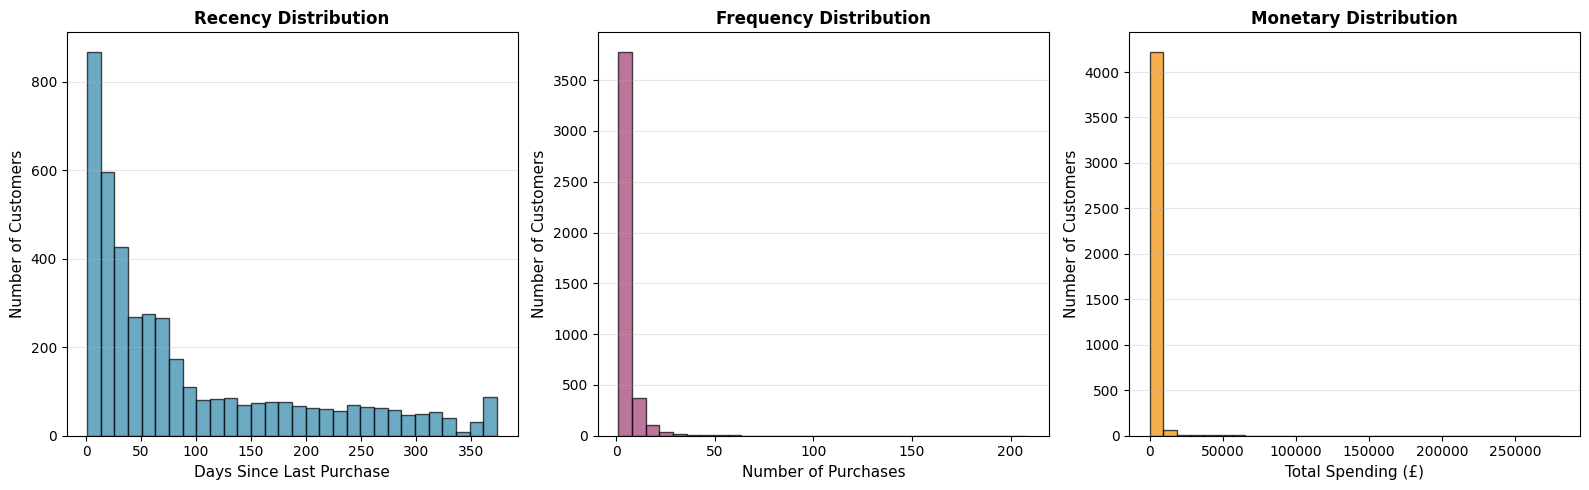

RFM distributions visualized


In [64]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Recency
axes[0].hist(rfm['Recency'], bins=30, color='#2E86AB', edgecolor='black', alpha=0.7)
axes[0].set_title('Recency Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Days Since Last Purchase', fontsize=11)
axes[0].set_ylabel('Number of Customers', fontsize=11)
axes[0].grid(True, alpha=0.3, axis='y')

# Frequency
axes[1].hist(rfm['Frequency'], bins=30, color='#A23B72', edgecolor='black', alpha=0.7)
axes[1].set_title('Frequency Distribution', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Number of Purchases', fontsize=11)
axes[1].set_ylabel('Number of Customers', fontsize=11)
axes[1].grid(True, alpha=0.3, axis='y')

# Monetary
axes[2].hist(rfm['Monetary'], bins=30, color='#F18F01', edgecolor='black', alpha=0.7)
axes[2].set_title('Monetary Distribution', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Total Spending (£)', fontsize=11)
axes[2].set_ylabel('Number of Customers', fontsize=11)
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print('RFM distributions visualized')

## Additional Features for Better Segmentation

Beyond RFM, let's create more features that help our model

In [65]:
# 1. Average Order Value (AOV)
# How much does each customer spend PER purchase?
rfm['AOV'] = rfm['Monetary'] / rfm['Frequency']

# 2. Customer Lifetime Value (CLV) - Same as Monetary in this case
# But we can also scale it
rfm['CLV'] = rfm['Monetary']

# 3. Days as Customer
# How long have they been a customer? (First purchase to last purchase)
first_purchase = clean_df.groupby('CustomerID')['InvoiceDate'].min()
last_purchase = clean_df.groupby('CustomerID')['InvoiceDate'].max()
rfm['Days_as_Customer'] = (last_purchase - first_purchase).dt.days

# 4. Purchase Rate
# How many purchases per day they've been a customer?
rfm['Purchase_Rate'] = rfm['Frequency'] / (rfm['Days_as_Customer'] + 1)

print('Additional features created!')
print(rfm.head(10))

Additional features created!
            Recency  Frequency  Monetary           AOV       CLV  \
CustomerID                                                         
12346.0         326          1  77183.60  77183.600000  77183.60   
12347.0           2          7   4310.00    615.714286   4310.00   
12348.0          75          4   1797.24    449.310000   1797.24   
12349.0          19          1   1757.55   1757.550000   1757.55   
12350.0         310          1    334.40    334.400000    334.40   
12352.0          36          8   2506.04    313.255000   2506.04   
12353.0         204          1     89.00     89.000000     89.00   
12354.0         232          1   1079.40   1079.400000   1079.40   
12355.0         214          1    459.40    459.400000    459.40   
12356.0          23          3   2811.43    937.143333   2811.43   

            Days_as_Customer  Purchase_Rate  
CustomerID                                   
12346.0                    0       1.000000  
12347.0         

## Final Feature Set

In [66]:
print('='*80)
print('FINAL FEATURES FOR SEGMENTATION')
print('='*80)

print(f'\nTotal Customers: {len(rfm)}')
print(f'\nFeatures Created:')
print(f'  1. Recency - Days since last purchase')
print(f'  2. Frequency - Number of purchases')
print(f'  3. Monetary - Total amount spent')
print(f'  4. AOV - Average Order Value')
print(f'  5. CLV - Customer Lifetime Value')
print(f'  6. Days_as_Customer - Customer tenure')
print(f'  7. Purchase_Rate - Purchases per day')

print(f'\nDataset shape: {rfm.shape}')
print(f'\nDataset info:')
print(rfm.info())

# Getting the top 5 most valuable customers
top_5 = rfm.nlargest(5, "Monetary")
print(top_5)

FINAL FEATURES FOR SEGMENTATION

Total Customers: 4338

Features Created:
  1. Recency - Days since last purchase
  2. Frequency - Number of purchases
  3. Monetary - Total amount spent
  4. AOV - Average Order Value
  5. CLV - Customer Lifetime Value
  6. Days_as_Customer - Customer tenure
  7. Purchase_Rate - Purchases per day

Dataset shape: (4338, 7)

Dataset info:
<class 'pandas.DataFrame'>
Index: 4338 entries, 12346.0 to 18287.0
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Recency           4338 non-null   int64  
 1   Frequency         4338 non-null   int64  
 2   Monetary          4338 non-null   float64
 3   AOV               4338 non-null   float64
 4   CLV               4338 non-null   float64
 5   Days_as_Customer  4338 non-null   int64  
 6   Purchase_Rate     4338 non-null   float64
dtypes: float64(4), int64(3)
memory usage: 271.1 KB
None
            Recency  Frequency   Monetary        

## Check for Missing Values

In [67]:
# Check for any missing values
print('Missing values:')
print(rfm.isnull().sum())


Missing values:
Recency             0
Frequency           0
Monetary            0
AOV                 0
CLV                 0
Days_as_Customer    0
Purchase_Rate       0
dtype: int64


## Save RFM Features for Next Step

In [68]:
# Save to CSV 
rfm.to_csv('rfm_features.csv')

print('RFM features saved to rfm_features.csv')

RFM features saved to rfm_features.csv
